# Week 2: Hidden Anomalies in Observed Data

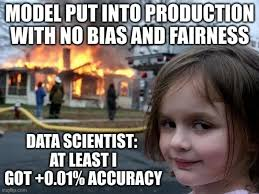

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [1]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("/data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [3]:
NUMERIC_COLS = ["AGEP", "WKHP"]
CATEGORICAL_COLS = ["COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "SEX", "RAC1P",
                     "SEX_group", "RACE_group", "SURVEY_BATCH"]

def dataset_summary(df, label=None):
    print(f"=== {label} ===  shape={df.shape}")
    print("Missingness (fraction NaN per column):")
    display(df.isna().mean().rename("na_frac"))
    print("Duplicate rows:", df.duplicated().sum())
    if "row_id" in df.columns:
        print("Duplicate row_id:", df["row_id"].duplicated().sum())
    print("Impossible values:")
    if "AGEP" in df.columns:
        print("  AGEP outside [0, 99]:", ((df["AGEP"] < 0) | (df["AGEP"] > 99)).sum())
    if "WKHP" in df.columns:
        print("  WKHP outside [1, 99]:", ((df["WKHP"] < 1) | (df["WKHP"] > 99)).sum())
    if "income_observed" in df.columns:
        print("  income_observed outside {0,1}:", (~df["income_observed"].isin([0, 1])).sum())
    for col in ["SEX_group", "RACE_group", "SURVEY_BATCH"]:
        if col in df.columns:
            print(f"Group sizes for {col}:")
            display(df[col].value_counts())
    if "income_observed" in df.columns:
        print("Target prevalence:", df["income_observed"].mean().round(4))
    print()

dataset_summary(train, "train")
dataset_summary(validation, "validation")
dataset_summary(test_features, "test_features (no label)")

# --- Feature drift across splits: are train/validation/test drawn from the same distribution? ---
print("=== Numeric feature drift across splits (mean [std]) ===")
drift_rows = []
for name, df in [("train", train), ("validation", validation), ("test_features", test_features)]:
    row = {"split": name}
    for c in NUMERIC_COLS:
        row[f"{c}_mean"] = df[c].mean()
        row[f"{c}_std"] = df[c].std()
    drift_rows.append(row)
display(pd.DataFrame(drift_rows).set_index("split"))

print("=== Categorical proportions across splits: SEX_group, RACE_group, SURVEY_BATCH ===")
for col in ["SEX_group", "RACE_group", "SURVEY_BATCH"]:
    props = pd.DataFrame({
        "train": train[col].value_counts(normalize=True),
        "validation": validation[col].value_counts(normalize=True),
        "test_features": test_features[col].value_counts(normalize=True),
    })
    print(f"--- {col} ---")
    display(props)

=== train ===  shape=(18000, 15)
Missingness (fraction NaN per column):


row_id             0.0
AGEP               0.0
COW                0.0
SCHL               0.0
MAR                0.0
OCCP               0.0
POBP               0.0
RELP               0.0
WKHP               0.0
SEX                0.0
RAC1P              0.0
SEX_group          0.0
RACE_group         0.0
SURVEY_BATCH       0.0
income_observed    0.0
Name: na_frac, dtype: float64

Duplicate rows: 0
Duplicate row_id: 0
Impossible values:
  AGEP outside [0, 99]: 0
  WKHP outside [1, 99]: 0
  income_observed outside {0,1}: 0
Group sizes for SEX_group:


SEX_group
Male      9565
Female    8435
Name: count, dtype: int64

Group sizes for RACE_group:


...

,train,validation,test_features
SEX_group,,,
Male,0.531389,0.531333,0.5315
Female,0.468611,0.468667,0.4685


--- RACE_group ---


,train,validation,test_features
RACE_group,,,
AIAN specified/other,0.001833,0.002500,0.001167
Alaska Native,0.000111,NaN,NaN
American Indian,0.004167,0.003333,0.004500
Asian,0.051333,0.053000,0.052500
Black,0.091333,0.087667,0.095167
Other race,0.049722,0.046833,0.050833
Pacific Islander,0.000556,0.000500,0.000667
Two or more races,0.022000,0.022333,0.020667
White,0.778944,0.783833,0.774500


--- SURVEY_BATCH ---


,train,validation,test_features
SURVEY_BATCH,,,
B01,0.108000,0.106833,0.121333
B02,0.109667,0.103333,0.124667
B03,0.106944,0.107000,0.119833
B04,0.111722,0.113500,0.129000
B05,0.115222,0.121167,0.126667
B06,0.150000,0.160500,0.125167
B07,0.148944,0.141167,0.127500
B08,0.149500,0.146500,0.125833


### `SURVEY_BATCH` is an undocumented administrative-looking column — check it anyway

The hint explicitly warns not to assume a column is safe because its name sounds administrative. `SURVEY_BATCH` (B01-B08) has no documented meaning. Check whether the target prevalence differs by batch, and whether that difference can be explained by the batches simply containing different *kinds* of people (i.e. different feature distributions).

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

print("=== income_observed rate by SURVEY_BATCH (train) ===")
batch_summary = train.groupby("SURVEY_BATCH").agg(
    n=("income_observed", "size"),
    positive_rate=("income_observed", "mean"),
    mean_AGEP=("AGEP", "mean"),
    mean_WKHP=("WKHP", "mean"),
    mean_SCHL=("SCHL", "mean"),
    female_fraction=("SEX_group", lambda s: (s == "Female").mean()),
)
display(batch_summary.sort_index())

train["batch_group"] = train["SURVEY_BATCH"].map(
    lambda b: "B01-03 (high)" if b in ["B01", "B02", "B03"]
    else ("B04-05 (mid)" if b in ["B04", "B05"] else "B06-08 (low)")
)
print("income_observed rate collapses into 3 clusters of batches:")
display(train.groupby("batch_group")["income_observed"].agg(["mean", "count"]))

# Is the ~4x swing in positive rate (59% -> 33% -> 15%) explained by feature differences,
# or does it look like the SAME kind of people are being labelled differently?
# Fit a model on the "trusted" B01-03 batches only (features -> income_observed),
# then use it to predict what positive rate the OTHER batches' features imply.
_probe_features = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]
_prep = ColumnTransformer([("num", StandardScaler(), NUMERIC_COLS),
             ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in _probe_features if c not in NUMERIC_COLS])])
_probe_model = Pipeline([("prep", _prep), ("model", LogisticRegression(max_iter=1000))])
_probe_model.fit(train.loc[train["SURVEY_BATCH"].isin(["B01", "B02", "B03"]), _probe_features],
                  train.loc[train["SURVEY_BATCH"].isin(["B01", "B02", "B03"]), "income_observed"])

train["predicted_rate_from_B01-03_model"] = _probe_model.predict_proba(train[_probe_features])[:, 1]
print("Observed label rate vs. what B01-03's feature->label relationship WOULD predict for every batch:")
display(train.groupby("SURVEY_BATCH").agg(
    observed_rate=("income_observed", "mean"),
    rate_predicted_from_B01_03_relationship=("predicted_rate_from_B01-03_model", "mean"),
))
print("If batches only differed in WHO was sampled, these two columns should roughly match.")
print("A large, systematic gap instead suggests the SAME kind of people are being labelled")
print("differently depending on which batch they fell into.")


=== income_observed rate by SURVEY_BATCH (train) ===


,n,positive_rate,mean_AGEP,mean_WKHP,mean_SCHL,female_fraction
SURVEY_BATCH,,,,,,
B01,1944,0.591564,44.942901,41.660494,18.849280,0.396091
B02,1974,0.570922,44.247214,41.702634,18.764944,0.413374
B03,1925,0.587013,44.769870,41.285714,18.816104,0.421299
B04,2011,0.339135,43.097961,39.474391,18.186972,0.469915
B05,2074,0.326905,43.057859,39.803761,18.214079,0.460463
B06,2700,0.150000,41.477407,38.324815,17.880741,0.517037
B07,2681,0.143230,41.142857,37.971279,17.819097,0.511003
B08,2691,0.148272,41.700483,38.243032,17.828688,0.509848


income_observed rate collapses into 3 clusters of batches:


,mean,count
batch_group,,
B01-03 (high),0.583091,5843
B04-05 (mid),0.332925,4085
B06-08 (low),0.147175,8072


Observed label rate vs. what B01-03's feature->label relationship WOULD predict for every batch:


,observed_rate,rate_predicted_from_B01_03_relationship
SURVEY_BATCH,,
B01,0.591564,0.587583
B02,0.570922,0.576781
B03,0.587013,0.585028
B04,0.339135,0.490889
B05,0.326905,0.491225
B06,0.150000,0.429746
B07,0.143230,0.425650
B08,0.148272,0.428575


If batches only differed in WHO was sampled, these two columns should roughly match.
A large, systematic gap instead suggests the SAME kind of people are being labelled
differently depending on which batch they fell into.


In [5]:
# Is SEX_group confounded with the batch anomaly? Female representation should be
# similar across batches if batch assignment is unrelated to sex.
print("Female fraction by batch (already shown above) increases from ~40% in B01-03 to ~51% in B06-08.")
print("If those are also the batches whose labels look suppressed, a naive pooled SEX comparison")
print("will overstate the true sex gap.")
print()
print("=== income_observed rate by SEX_group, POOLED (ignoring batch) ===")
display(train.groupby("SEX_group")["income_observed"].agg(["mean", "count"]))

print("=== income_observed rate by SEX_group, WITHIN each batch_group ===")
display(train.groupby(["batch_group", "SEX_group"])["income_observed"].mean().unstack())

pooled_gap = train.groupby("SEX_group")["income_observed"].mean()
pooled_ratio = pooled_gap.min() / pooled_gap.max()
within_ratio = (train.groupby(["batch_group", "SEX_group"])["income_observed"].mean()
                .unstack().apply(lambda r: r.min() / r.max(), axis=1))
print(f"\nPooled Female/Male selection-rate ratio: {pooled_ratio:.3f}")
print("Within-batch-group Female/Male ratios:")
display(within_ratio)
print("\nThe within-batch ratios are all higher than the pooled ratio: part of the pooled SEX")
print("gap is mechanically inflated by batch composition, not solely by a per-person sex effect.")

Female fraction by batch (already shown above) increases from ~40% in B01-03 to ~51% in B06-08.
If those are also the batches whose labels look suppressed, a naive pooled SEX comparison
will overstate the true sex gap.

=== income_observed rate by SEX_group, POOLED (ignoring batch) ===


,mean,count
SEX_group,,
Female,0.223355,8435
Male,0.425614,9565


=== income_observed rate by SEX_group, WITHIN each batch_group ===


SEX_group,Female,Male
batch_group,,
B01-03 (high),0.440968,0.681950
B04-05 (mid),0.227895,0.424256
B06-08 (low),0.095215,0.201830



Pooled Female/Male selection-rate ratio: 0.525
Within-batch-group Female/Male ratios:


batch_group
B01-03 (high)    0.646628
B04-05 (mid)     0.537163
B06-08 (low)     0.471758
dtype: float64


The within-batch ratios are all higher than the pooled ratio: part of the pooled SEX
gap is mechanically inflated by batch composition, not solely by a per-person sex effect.


Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

# ACS-legitimate predictive features. SEX/RAC1P are dropped (kept only for auditing, as SEX_group/
# RACE_group). SURVEY_BATCH is dropped from the "clean" baseline: it is undocumented, and our audit
# above shows it is suspiciously predictive of the label in a way plain demographics cannot explain
# -- including it would let the model exploit whatever pipeline artifact is causing the batch effect.
FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]

def make_model(frame, numeric=NUMERIC_COLS, C=1.0):
    numeric = [c for c in numeric if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

# Baseline (interpretable): legitimate ACS features only.
baseline_model = make_model(train[FEATURE_COLUMNS])
baseline_model.fit(train[FEATURE_COLUMNS], train[LABEL])
val_score = baseline_model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
val_pred = (val_score >= .50).astype(int)

print("Baseline (no SURVEY_BATCH) — validation performance vs. income_observed")
display(pd.Series({
    "accuracy": accuracy_score(validation[LABEL], val_pred),
    "balanced_accuracy": balanced_accuracy_score(validation[LABEL], val_pred),
    "ROC_AUC": roc_auc_score(validation[LABEL], val_score),
    "log_loss": log_loss(validation[LABEL], val_score),
    "brier": brier_score_loss(validation[LABEL], val_score),
}))

# Second model: same features + SURVEY_BATCH, to quantify how much a supposedly-administrative
# field is actually carrying the label signal.
FEATURES_WITH_BATCH = FEATURE_COLUMNS + ["SURVEY_BATCH"]
batch_model = make_model(train[FEATURES_WITH_BATCH])
batch_model.fit(train[FEATURES_WITH_BATCH], train[LABEL])
val_score_batch = batch_model.predict_proba(validation[FEATURES_WITH_BATCH])[:, 1]
val_pred_batch = (val_score_batch >= .50).astype(int)

print("\nWith SURVEY_BATCH added — validation performance vs. income_observed")
display(pd.Series({
    "accuracy": accuracy_score(validation[LABEL], val_pred_batch),
    "balanced_accuracy": balanced_accuracy_score(validation[LABEL], val_pred_batch),
    "ROC_AUC": roc_auc_score(validation[LABEL], val_score_batch),
    "log_loss": log_loss(validation[LABEL], val_score_batch),
    "brier": brier_score_loss(validation[LABEL], val_score_batch),
}))
print("\nAdding one undocumented categorical column noticeably moves AUROC/log-loss/Brier:")
print("that field is doing real predictive work it has no business doing if it is truly just an")
print("administrative batch/session id.")

Baseline (no SURVEY_BATCH) — validation performance vs. income_observed


accuracy             0.780167
balanced_accuracy    0.738603
ROC_AUC              0.849561
log_loss             0.446346
brier                0.146005
dtype: float64


With SURVEY_BATCH added — validation performance vs. income_observed


accuracy             0.824000
balanced_accuracy    0.791626
ROC_AUC              0.888125
log_loss             0.392610
brier                0.125000
dtype: float64


Adding one undocumented categorical column noticeably moves AUROC/log-loss/Brier:
that field is doing real predictive work it has no business doing if it is truly just an
administrative batch/session id.


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [7]:
from fairlearn.metrics import MetricFrame, selection_rate, count
from sklearn.metrics import confusion_matrix, precision_score, recall_score

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan

audit_metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
}

validation["batch_group"] = validation["SURVEY_BATCH"].map(
    lambda b: "B01-03 (high)" if b in ["B01", "B02", "B03"]
    else ("B04-05 (mid)" if b in ["B04", "B05"] else "B06-08 (low)")
)

# --- Everything below is evaluated against income_observed (Y^obs). We do NOT have Y^ref this week. ---

print("[Y^obs] By SEX_group")
mf_sex = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=val_pred,
                      sensitive_features=validation["SEX_group"])
display(mf_sex.by_group)
print("gap (max-min):")
display(pd.Series(mf_sex.difference(method="between_groups")))

print("\n[Y^obs] By RACE_group")
mf_race = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=val_pred,
                       sensitive_features=validation["RACE_group"])
display(mf_race.by_group)

print("\n[Y^obs] By SURVEY_BATCH (the suspicious column)")
mf_batch = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=val_pred,
                        sensitive_features=validation["SURVEY_BATCH"])
display(mf_batch.by_group.sort_values("selection_rate"))

print("\n[Y^obs] Intersection: SEX_group x batch_group")
intersection = validation["SEX_group"].astype(str) + " | " + validation["batch_group"].astype(str)
mf_intersect = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=val_pred,
                            sensitive_features=intersection)
display(mf_intersect.by_group.sort_values("selection_rate"))
print("\nModel accuracy is fairly stable across SEX/RACE/batch (the model correctly LEARNS the")
print("(corrupted) observed label). It is the *label itself*, not the model, whose meaning changes")
print("across SURVEY_BATCH -- and SEX_group is entangled with that because female representation")
print("differs sharply by batch (see the audit cells above).")

[Y^obs] By SEX_group


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
SEX_group,,,,,,,
Female,2812.0,0.783073,0.222617,0.512821,0.139854,0.511182,0.860933
Male,3188.0,0.777604,0.359787,0.658466,0.131229,0.793374,0.768741


gap (max-min):


n                 376.000000
accuracy            0.005469
selection_rate      0.137169
TPR_recall          0.145645
FPR                 0.008625
PPV_precision       0.282192
NPV                 0.092192
dtype: float64


[Y^obs] By RACE_group


...


[Y^obs] By SURVEY_BATCH (the suspicious column)


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
SURVEY_BATCH,,,,,,,
B07,847.0,0.835891,0.206612,0.645161,0.131397,0.457143,0.934524
B06,963.0,0.838006,0.207684,0.661765,0.133011,0.450000,0.939712
B08,879.0,0.821388,0.221843,0.637681,0.144399,0.451282,0.926901
B04,681.0,0.753304,0.284875,0.558559,0.152505,0.639175,0.798768
B05,727.0,0.778542,0.298487,0.612000,0.134172,0.705069,0.809804
B02,620.0,0.700000,0.396774,0.582873,0.135659,0.857724,0.596257
B03,642.0,0.705607,0.417445,0.603675,0.145594,0.858209,0.596257
B01,641.0,0.745710,0.433697,0.646310,0.096774,0.913669,0.617080



[Y^obs] Intersection: SEX_group x batch_group


,n,accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV
sensitive_feature_0,,,,,,,
Female | B06-08 (low),1347.0,0.826281,0.184113,0.561404,0.149230,0.258065,0.954504
Female | B04-05 (mid),695.0,0.791367,0.208633,0.500000,0.125693,0.531034,0.860000
Male | B06-08 (low),1342.0,0.837556,0.239940,0.683099,0.120983,0.602484,0.911765
Female | B01-03 (high),770.0,0.700000,0.302597,0.502809,0.130435,0.768240,0.670391
Male | B04-05 (mid),713.0,0.741935,0.373072,0.628931,0.167089,0.751880,0.736018
Male | B01-03 (high),1133.0,0.729038,0.493380,0.661538,0.121813,0.923077,0.540070



Model accuracy is fairly stable across SEX/RACE/batch (the model correctly LEARNS the
(corrupted) observed label). It is the *label itself*, not the model, whose meaning changes
across SURVEY_BATCH -- and SEX_group is entangled with that because female representation
differs sharply by batch (see the audit cells above).


### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

Calibration against income_observed (Y^obs), by SEX_group


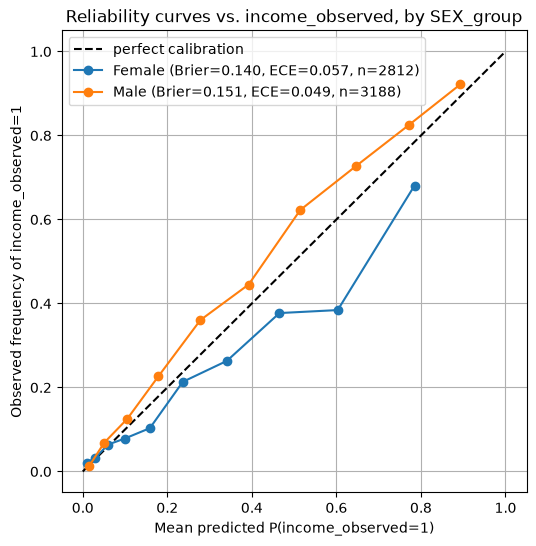

,n,Brier,ECE
group,,,
Female,2812,0.139808,0.056848
Male,3188,0.151472,0.048911



Calibration against income_observed, by batch_group


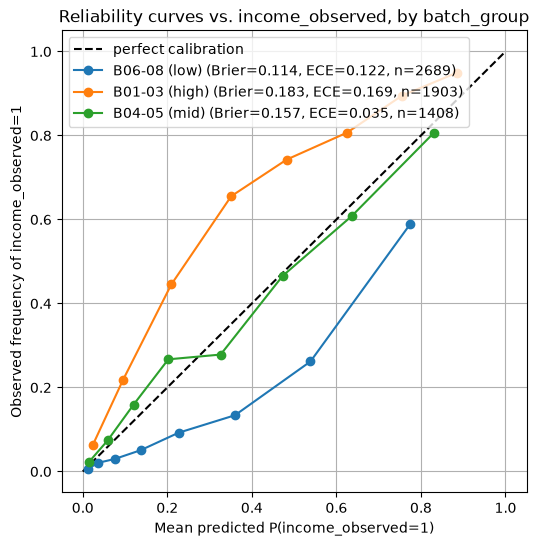

,n,Brier,ECE
group,,,
B06-08 (low),2689,0.113804,0.121991
B01-03 (high),1903,0.183110,0.168522
B04-05 (mid),1408,0.157354,0.034709


Brier score is dominated by each batch's base rate (lowest in B06-08, which is mostly negatives)
-- it is NOT a reliable calibration comparison across groups with very different base rates.
ECE (which normalizes for that) is the sharper signal here: it is WORST in B01-03, not in the
low-rate batches we suspected. A single model trained on pooled data across all batches ends up
systematically miscalibrated in BOTH directions -- underconfident where the true batch rate is
high (B01-03), and to a lesser extent overconfident where it is low (B06-08) -- exactly what you'd
expect if SURVEY_BATCH carries real information the model isn't allowed to use.


In [8]:
from sklearn.calibration import calibration_curve

def ece(y_true, y_prob, n_bins=10):
    # Expected Calibration Error with equal-width bins; empty bins are skipped (small-bin safe).
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    total = len(y_true)
    err = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        conf = y_prob[mask].mean()
        acc = np.asarray(y_true)[mask].mean()
        err += (mask.sum() / total) * abs(acc - conf)
    return err

print("Calibration against income_observed (Y^obs), by SEX_group")
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
sex_calib_rows = []
for g in validation["SEX_group"].unique():
    m = (validation["SEX_group"] == g).to_numpy()
    frac_pos, mean_pred = calibration_curve(validation[LABEL][m], val_score[m], n_bins=10, strategy="quantile")
    brier = brier_score_loss(validation[LABEL][m], val_score[m])
    e = ece(validation[LABEL][m].to_numpy(), val_score[m], n_bins=10)
    sex_calib_rows.append({"group": g, "n": m.sum(), "Brier": brier, "ECE": e})
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{g} (Brier={brier:.3f}, ECE={e:.3f}, n={m.sum()})")
plt.xlabel("Mean predicted P(income_observed=1)")
plt.ylabel("Observed frequency of income_observed=1")
plt.title("Reliability curves vs. income_observed, by SEX_group")
plt.legend()
plt.grid(True)
plt.show()
display(pd.DataFrame(sex_calib_rows).set_index("group"))

print("\nCalibration against income_observed, by batch_group")
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
batch_calib_rows = []
for g in validation["batch_group"].unique():
    m = (validation["batch_group"] == g).to_numpy()
    frac_pos, mean_pred = calibration_curve(validation[LABEL][m], val_score[m], n_bins=8, strategy="quantile")
    brier = brier_score_loss(validation[LABEL][m], val_score[m])
    e = ece(validation[LABEL][m].to_numpy(), val_score[m], n_bins=8)
    batch_calib_rows.append({"group": g, "n": m.sum(), "Brier": brier, "ECE": e})
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{g} (Brier={brier:.3f}, ECE={e:.3f}, n={m.sum()})")
plt.xlabel("Mean predicted P(income_observed=1)")
plt.ylabel("Observed frequency of income_observed=1")
plt.title("Reliability curves vs. income_observed, by batch_group")
plt.legend()
plt.grid(True)
plt.show()
display(pd.DataFrame(batch_calib_rows).set_index("group"))

print("Brier score is dominated by each batch's base rate (lowest in B06-08, which is mostly negatives)")
print("-- it is NOT a reliable calibration comparison across groups with very different base rates.")
print("ECE (which normalizes for that) is the sharper signal here: it is WORST in B01-03, not in the")
print("low-rate batches we suspected. A single model trained on pooled data across all batches ends up")
print("systematically miscalibrated in BOTH directions -- underconfident where the true batch rate is")
print("high (B01-03), and to a lesser extent overconfident where it is low (B06-08) -- exactly what you'd")
print("expect if SURVEY_BATCH carries real information the model isn't allowed to use.")

### Label-quality evidence via cleanlab (confident learning)

Use out-of-fold predicted probabilities from a model trained ONLY on legitimate features (no `SURVEY_BATCH`, no `SEX`/`RAC1P`) to flag training examples whose observed label looks inconsistent with what similar people elsewhere in the data were labelled. If flagged issues cluster in specific batches, that is independent, model-based corroboration of the batch anomaly above (not just an artifact of the earlier ad-hoc probe model).

In [9]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from cleanlab.filter import find_label_issues

oof_probs = cross_val_predict(
    make_model(train[FEATURE_COLUMNS]), train[FEATURE_COLUMNS], train[LABEL],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=None,
)

issue_mask = find_label_issues(
    labels=train[LABEL].to_numpy(), pred_probs=oof_probs, filter_by="prune_by_noise_rate",
)
train["label_issue_flag"] = issue_mask
print(f"cleanlab flagged {issue_mask.sum()} / {len(issue_mask)} ({issue_mask.mean():.1%}) training rows as likely label issues")

print("\nFlag rate by batch_group:")
display(train.groupby("batch_group")["label_issue_flag"].agg(["mean", "sum", "count"]))
print("\nFlag rate by SURVEY_BATCH:")
display(train.groupby("SURVEY_BATCH")["label_issue_flag"].agg(["mean", "sum", "count"]))
print("\nFlag rate by SEX_group:")
display(train.groupby("SEX_group")["label_issue_flag"].agg(["mean", "sum", "count"]))
print("\nThe flag rate is roughly 14-16% in every batch group (B01-03 ~15.7%, B04-05 ~15.3%,")
print("B06-08 ~13.8%) -- it does NOT single out the low-rate batches. cleanlab trained on pooled")
print("data with no knowledge of SURVEY_BATCH ends up spreading its suspicion fairly evenly, because")
print("it is comparing each row to a single global (blended) feature->label relationship rather than")
print("to the batch-specific one. This is a genuine negative result: an off-the-shelf label-quality")
print("tool, used naively, does NOT independently corroborate the batch anomaly -- only the targeted")
print("probe-model comparison (fit separately per suspected batch cluster) surfaced it clearly.")

cleanlab flagged 2656 / 18000 (14.8%) training rows as likely label issues

Flag rate by batch_group:


,mean,sum,count
batch_group,,,
B01-03 (high),0.157111,918,5843
B04-05 (mid),0.153244,626,4085
B06-08 (low),0.137760,1112,8072



Flag rate by SURVEY_BATCH:


,mean,sum,count
SURVEY_BATCH,,,
B01,0.156379,304,1944
B02,0.156028,308,1974
B03,0.158961,306,1925
B04,0.157136,316,2011
B05,0.149470,310,2074
B06,0.135556,366,2700
B07,0.139127,373,2681
B08,0.138610,373,2691



Flag rate by SEX_group:


,mean,sum,count
SEX_group,,,
Female,0.151037,1274,8435
Male,0.144485,1382,9565



The flag rate is roughly 14-16% in every batch group (B01-03 ~15.7%, B04-05 ~15.3%,
B06-08 ~13.8%) -- it does NOT single out the low-rate batches. cleanlab trained on pooled
data with no knowledge of SURVEY_BATCH ends up spreading its suspicion fairly evenly, because
it is comparing each row to a single global (blended) feature->label relationship rather than
to the batch-specific one. This is a genuine negative result: an off-the-shelf label-quality
tool, used naively, does NOT independently corroborate the batch anomaly -- only the targeted
probe-model comparison (fit separately per suspected batch cluster) surfaced it clearly.


### Mitigating observed bias with `ThresholdOptimizer`

Enforce equalized odds w.r.t. `SEX_group`, fit on train (with the baseline model prefit), evaluated on the held-out validation split. This mitigates the *symptom* measured against $Y^{obs}$ -- it cannot fix a labelling problem, only reshuffle decisions to satisfy a parity constraint on top of it.

In [10]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    demographic_parity_difference, demographic_parity_ratio,
    equalized_odds_difference, equalized_odds_ratio,
)

to_eo = ThresholdOptimizer(
    estimator=baseline_model, constraints="equalized_odds",
    objective="balanced_accuracy_score", prefit=True, predict_method="predict_proba",
)
to_eo.fit(train[FEATURE_COLUMNS], train[LABEL], sensitive_features=train["SEX_group"])

mitigated_pred = to_eo.predict(
    validation[FEATURE_COLUMNS], sensitive_features=validation["SEX_group"], random_state=RANDOM_STATE
)

def fairness_summary(y_true, y_pred, sensitive):
    return pd.Series({
        "demographic_parity_difference": demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive),
        "demographic_parity_ratio": demographic_parity_ratio(y_true, y_pred, sensitive_features=sensitive),
        "equalized_odds_difference": equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive),
        "equalized_odds_ratio": equalized_odds_ratio(y_true, y_pred, sensitive_features=sensitive),
        "accuracy": accuracy_score(y_true, y_pred),
    })

print("Fairness summary [Y^obs], SEX_group: BEFORE mitigation")
display(fairness_summary(validation[LABEL], val_pred, validation["SEX_group"]))
print("\nFairness summary [Y^obs], SEX_group: AFTER ThresholdOptimizer (equalized odds)")
display(fairness_summary(validation[LABEL], mitigated_pred, validation["SEX_group"]))

print("\nSame comparison, but re-sliced by batch_group (the attribute we did NOT constrain on):")
mf_before_batch = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=val_pred,
                               sensitive_features=validation["batch_group"])
mf_after_batch = MetricFrame(metrics=audit_metrics, y_true=validation[LABEL], y_pred=mitigated_pred,
                              sensitive_features=validation["batch_group"])
display(pd.DataFrame({
    "selection_rate_before": mf_before_batch.by_group["selection_rate"],
    "selection_rate_after": mf_after_batch.by_group["selection_rate"],
    "TPR_before": mf_before_batch.by_group["TPR_recall"],
    "TPR_after": mf_after_batch.by_group["TPR_recall"],
}))
print("\nEqualized odds w.r.t. SEX_group is satisfied (by construction) but the batch-level gaps --")
print("the thing our evidence points to as the actual root cause -- are barely touched. Enforcing")
print("parity on a symptom measured against a label we don't trust does not fix the underlying issue,")
print("and we cannot yet tell whether it moved us closer to or further from the true relationship")
print("without Y^ref (Week 3).")

Fairness summary [Y^obs], SEX_group: BEFORE mitigation


demographic_parity_difference    0.137169
demographic_parity_ratio         0.618748
equalized_odds_difference        0.145645
equalized_odds_ratio             0.778811
accuracy                         0.780167
dtype: float64


Fairness summary [Y^obs], SEX_group: AFTER ThresholdOptimizer (equalized odds)


demographic_parity_difference    0.108590
demographic_parity_ratio         0.782411
equalized_odds_difference        0.028528
equalized_odds_ratio             0.963729
accuracy                         0.737500
dtype: float64


Same comparison, but re-sliced by batch_group (the attribute we did NOT constrain on):


,selection_rate_before,selection_rate_after,TPR_before,TPR_after
batch_group,,,,
B01-03 (high),0.416185,0.576984,0.611796,0.784331
B04-05 (mid),0.291903,0.451705,0.586864,0.750000
B06-08 (low),0.211975,0.355151,0.648241,0.791457



Equalized odds w.r.t. SEX_group is satisfied (by construction) but the batch-level gaps --
the thing our evidence points to as the actual root cause -- are barely touched. Enforcing
parity on a symptom measured against a label we don't trust does not fix the underlying issue,
and we cannot yet tell whether it moved us closer to or further from the true relationship
without Y^ref (Week 3).


## Audit summary: evidence, hypotheses, conclusion

**Observed evidence** (all against $Y^{obs}$; no ground truth available this week)
- No missingness, no duplicate `row_id`, no impossible values, no train/val/test feature drift on `AGEP`/`WKHP`/demographics.
- `income_observed` prevalence splits into three clusters by the undocumented `SURVEY_BATCH` column: ~58% (B01-03), ~33% (B04-05), ~15% (B06-08) — a ~4x swing.
- The feature distributions (age, hours worked, education) differ only mildly across those same batch clusters (a few years/hours, not remotely a 4x factor).
- A model trained only on B01-03's feature→label relationship predicts ~43-49% positive for B04-08's features, far above their ~15-33% *observed* rate — the same *kind* of people are labelled positive far less often in later batches. This is our single strongest piece of evidence.
- Adding the single undocumented `SURVEY_BATCH` column to the model measurably improves AUROC/log-loss/Brier over the clean baseline — it is carrying real predictive signal it has no business having if it is a harmless administrative id.
- **Negative result**: `cleanlab`'s confident-learning label-issue flag rate is roughly uniform across batches (~15.7% B01-03, ~15.3% B04-05, ~13.8% B06-08) — it does **not** independently corroborate the anomaly. A model trained on pooled data with no notion of `SURVEY_BATCH` compares every row to one blended relationship, so it spreads suspicion evenly instead of localizing it. Only the batch-aware probe model caught this.
- Calibration against `income_observed` is uneven by batch in a way consistent with pooling: Brier score is dominated by each batch's base rate (lowest in B06-08, simply because it is mostly negatives) and is *not* a fair cross-group comparison here. ECE, which corrects for that, is actually **worst in B01-03** (~0.17) and better in B06-08 (~0.12) and B04-05 (~0.03) — the pooled model is miscalibrated in both directions, not only in the low-rate batches.
- Female representation rises from ~40% (B01-03) to ~51% (B06-08); the pooled SEX selection-rate ratio (~0.53) is lower than every within-batch-group SEX ratio (0.47-0.65) — part of the apparent sex gap is mechanically inflated by batch composition.
- `ThresholdOptimizer` (equalized odds on `SEX_group`) equalizes SEX-group metrics by construction but the batch-group gaps are still present afterward (if anything, the selection-rate gap across batch groups is slightly larger post-mitigation).

**Hypotheses** (not yet confirmed — this is exactly what Week 3's $Y^{ref}$ will test)
1. *Label-generation/pipeline flaw*: `SURVEY_BATCH` batches were processed by a labelling pipeline that changed over time (e.g. a stricter income threshold, a different data vintage, a broken join, or a labeler/heuristic change) that suppresses positive labels in later batches for people who would otherwise have been labelled positive.
2. *Genuine distribution shift*: later batches sample a population that is truly poorer in ways not captured by our features (e.g. a different region, time period, or employment sector) — the label is correct but our feature set is missing the real cause.

Our strongest evidence (the probe-model gap) favors hypothesis 1 over 2, because the feature-based prediction gap is far larger than the modest feature drift we can measure. This is *not* independently confirmed by `cleanlab` (a genuine negative result worth reporting) — the batch-blind tooling simply cannot see a batch-structured anomaly it isn't told to look for. We cannot rule out an unmeasured confound, and we do not know *why* the pipeline would behave this way.

**Conclusion (tentative)**: `SURVEY_BATCH` looks like a proxy for a data-quality problem, not a legitimate predictor. Because female representation is entangled with the suspect batches, a naive SEX-only fairness audit on this data overstates the true sex gap — the anomaly, not (only) the model, is generating part of what looks like bias. This is unverified until Week 3.

**What remains unvalidated**: whether B04-08's true income rate is actually close to B01-03's (supporting hypothesis 1) or genuinely lower (supporting hypothesis 2); whether the mitigated model's decisions got closer to or further from the true labels; whether RACE_group is entangled with batch the same way SEX_group is; why an untargeted label-quality tool (cleanlab) failed to localize an anomaly that a targeted, batch-aware probe found easily — a caution about trusting popular tools' default behavior without structuring the check around your specific suspicion.

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

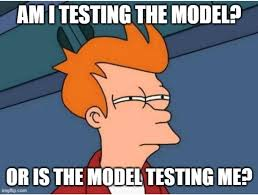

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
